In [1]:
%pip install git+https://github.com/alemartinello/dstapi

  Cloning https://github.com/alemartinello/dstapi to /private/var/folders/t7/z8cbkjgn1kvb4kbcpys245dw0000gn/T/pip-req-build-wdu_mpx0
  Running command git clone --filter=blob:none --quiet https://github.com/alemartinello/dstapi /private/var/folders/t7/z8cbkjgn1kvb4kbcpys245dw0000gn/T/pip-req-build-wdu_mpx0
  Resolved https://github.com/alemartinello/dstapi to commit d9eeb5a82cbc70b7d63b2ff44d92632fd77123a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [2]:
#importing pandas, matplotlib and numpy
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#importing API
from dstapi import DstApi

# **1.1 The Gini Coefficient and The Top 10 Percent Share**


In [3]:
IFOR41 = DstApi('IFOR41') 

In [4]:
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [5]:
#Building the query parameters for IFOR41 and setting variables
params41 = IFOR41._define_base_params(language='en')
def set_var(params, code, values):
    for v in params['variables']:
        if v['code'] == code:
            v['values'] = values
    return params

params41 = set_var(params41, 'ULLIG', ['70'])
params41 = set_var(params41, 'KOMMUNEDK', ['000'])
params41 = set_var(params41, 'TID', ['*'])

# Download the data and keep only the columns we need, rename them and convert the data types
gini = IFOR41.get_data(params=params41)
gini = gini.rename(columns={'TID': 'year', 'INDHOLD': 'gini'})[['year', 'gini']]
gini['year'] = gini['year'].astype(int)
gini['gini'] = pd.to_numeric(gini['gini'], errors='coerce')
gini = gini.sort_values('year').reset_index(drop=True)
gini.head()                                                    

,year,gini
0,1987,22.07
1,1988,22.06
2,1989,21.93
3,1990,22.16
4,1991,21.99


In [6]:
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [7]:
params32 = IFOR32._define_base_params(language='en')
params32 = set_var(params32, 'DECILGEN', ['*'])
params32 = set_var(params32, 'KOMMUNEDK', ['000'])
params32 = set_var(params32, 'TID', ['*'])

decile = IFOR32.get_data(params=params32)
decile = decile.rename(columns={'TID': 'year', 'INDHOLD': 'avg_income'})
decile['year'] = decile['year'].astype(int)

# Sum the average income of the richest decile (10th)
total_by_year = decile.groupby('year')['avg_income'].sum().rename('total_avg_income')
# Isolate the average income of the richest decile (10th)
top10 = decile.loc[decile['DECILGEN'] == 'Tenth decil', ['year', 'avg_income']].rename(columns={'avg_income': 'top10_avg_income'})

# Combine the two DataFrames and calculate the share of the top 10% income
top10 = top10.merge(total_by_year, on='year', validate='1:1')
top10['top10_share'] = 100*top10['top10_avg_income'] / top10['total_avg_income']
top10 = top10[['year', 'top10_share']]
top10.head()

,year,top10_share
0,2013,22.748373
1,2015,23.451122
2,1997,20.212349
3,2000,20.810058
4,1999,20.293497


In [8]:
# validate that the two DataFrames have the same years and merge them
df = pd.merge(gini, top10, on='year', validate='1:1')
df.head()

,year,gini,top10_share
0,1987,22.07,18.454866
1,1988,22.06,18.428870
2,1989,21.93,18.495170
3,1990,22.16,18.641480
4,1991,21.99,18.668346


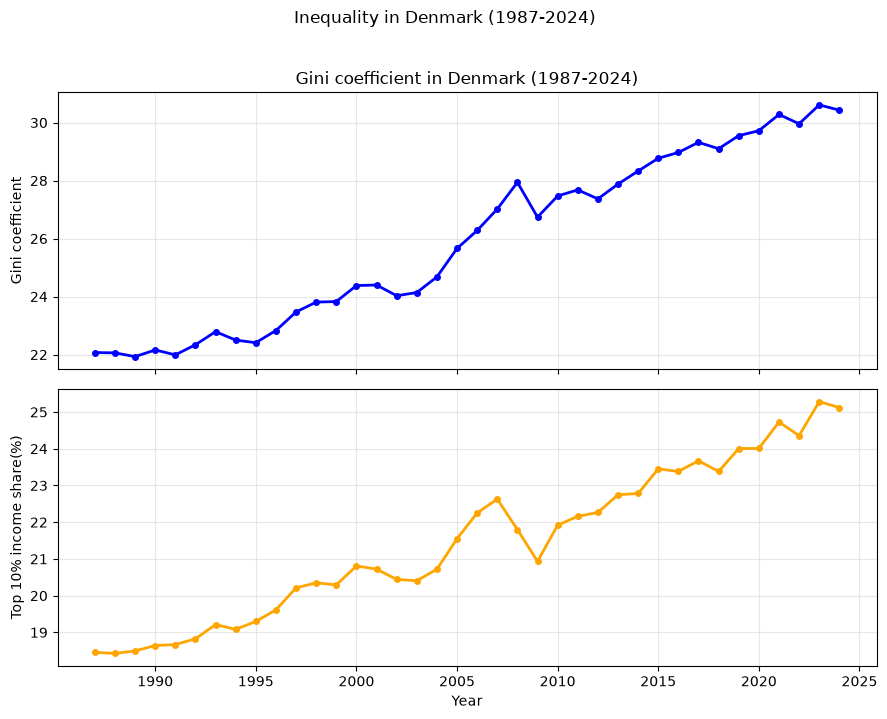

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

#Top panel: Gini coefficient over time
axes[0].plot(df['year'], df['gini'], color='blue', linewidth=2, marker='o', markersize=4)
axes[0].set_ylabel('Gini coefficient')
axes[0].set_title('Gini coefficient in Denmark (1987-2024)')
axes[0].grid(True, alpha=0.3)

#Bottom panel: Top 10% income share over time
axes[1].plot(df['year'], df['top10_share'], color='orange', linewidth=2, marker='o', markersize=4)
axes[1].set_ylabel('Top 10% income share(%)')
axes[1].set_xlabel('Year')
axes[1].xaxis.set_major_locator(plt.MultipleLocator(5))
axes[1].grid(True, alpha=0.3)

fig.suptitle('Inequality in Denmark (1987-2024)', y=1.02)
fig.tight_layout()
plt.show()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Inequality in Denmark (1987-2024)', y=1.02)
fig.tight_layout()
plt.show()

In [10]:
# Correlation between Gini coefficient and top 10% income share
corr = df['gini'].corr(df['top10_share'])
print(f"Correlation between Gini coefficient and top 10% income share: {corr:.3f}")

Correlation between Gini coefficient and top 10% income share: 0.982


# answer to the question: Describe how inequality in Denmark has developed since 1987. Do the two measures tell the same story?

Income inequality in Denmark has risen fairly steadily since 1987. The gini coefficient increased from about 22 in 1987 to around 30 in 2024, and the income share of the richest 10% rose from roughly 18.5% to 25% over the same period. Both measures a noticable dip around 2008-2009, likely due to the financial crisis, before resuming their upward trend. 

The two measures tell largely the same story: both show a clear, sustained increase in inequality over the period, and they move together closely, with a correlation of 0.982. This makes sense, since both capture aspects of the same underlying income distribution, where the gini coefficient summarizes inequality across the whole distribution, while the top 10% share focuses specifically on the top of it.

# **1.2 Prediction**

In [11]:
from scipy.optimize import minimize

#convert the years to "years since 1987"
t = (df['year'] - 1987).values
y = df['gini'].values

In [12]:
def sse(beta, t, y): 
    # Sum of squared errors for a polynomial regression model
    p = len(beta)-1
    y_pred = sum(beta[k]*t**k for k in range(p+1))
    return np.sum((y - y_pred)**2)

In [13]:
# Linear trend: beta = (beta_0, beta_1)
beta_linear0 = [y.mean(), 0]  # initial guess for beta_0 and beta_1
res_linear = minimize(sse, beta_linear0, args=(t, y))
beta_linear = res_linear.x
print('linear trend coefficients:', beta_linear)

# Qudratic trend: beta = (beta_0, beta_1, beta_2)
beta_quadratic0 = [y.mean(), 0, 0] 
res_quadratic = minimize(sse, beta_quadratic0, args=(t, y))
beta_quadratic = res_quadratic.x
print('quadratic trend coefficients:', beta_quadratic)

linear trend coefficients: [21.04275388  0.26354958]
quadratic trend coefficients: [2.13041543e+01 2.19983176e-01 1.17746752e-03]


In [14]:
# np.polyfit returns coefficients in descending order, so we need to reverse them to match our sse function
poly_linear = np.polyfit(t, y, 1)[::-1]
poly_quadratic = np.polyfit(t, y, 2)[::-1]

print('linear trend coefficients (np.polyfit):', poly_linear)
print('quadratic trend coefficients (np.polyfit):', poly_quadratic)

linear trend coefficients (np.polyfit): [21.04275304  0.26354962]
quadratic trend coefficients (np.polyfit): [2.13042004e+01 2.19975061e-01 1.17769085e-03]


In [15]:
def predict(beta, n):
    # Predicted gini coefficient for n years since 1987
    P = len(beta)-1
    return sum(beta[k]*n**k for k in range(P+1))

years_predict = [2030, 2040]

for yr in years_predict:
    n = yr - 1987
    pred_linear = predict(beta_linear, n)
    pred_quadratic = predict(beta_quadratic, n)
    print(f'{yr}: linear prediction = {pred_linear:.2f}, quadratic prediction = {pred_quadratic:.2f}')

2030: linear prediction = 32.38, quadratic prediction = 32.94
2040: linear prediction = 35.01, quadratic prediction = 36.27


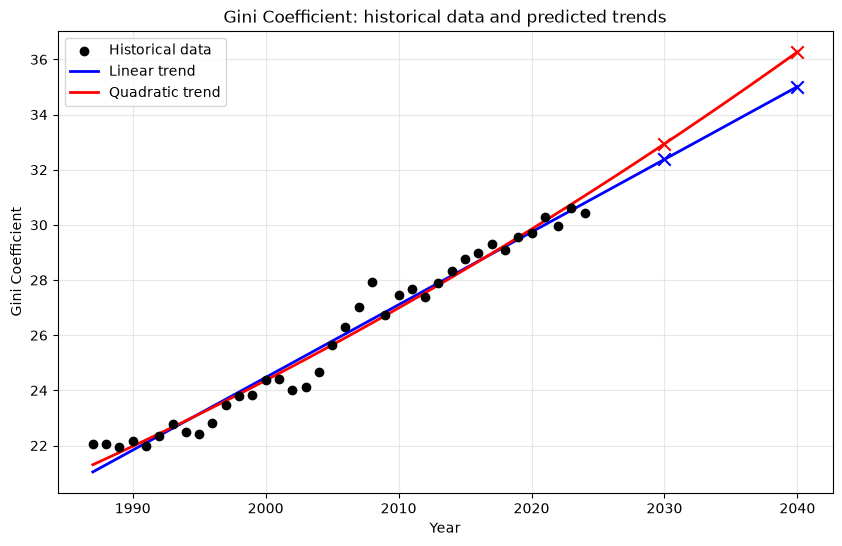

In [16]:
# Build a smooth range from 1987 to 2040 to draw fitted trend lines
fig, ax = plt.subplots(figsize=(10, 6))
t_plot = np.arange(0, (2040-1987)+1)
years_plot = t_plot + 1987

gini_linear_plot = predict(beta_linear, t_plot)
gini_quadratic_plot = predict(beta_quadratic, t_plot)

# Historical gini coefficient data
ax.scatter(df['year'], df['gini'], color='black', label='Historical data', zorder=5)

# Fitted trends, extrapolated out to 2040
ax.plot(years_plot, gini_linear_plot, color='blue', linewidth=2, label='Linear trend')
ax.plot(years_plot, gini_quadratic_plot, color='red', linewidth=2, label='Quadratic trend')

# Highlight the predictions for 2030 and 2040
for yr in years_predict:
    n = yr - 1987
    ax.scatter(yr, predict(beta_linear, n), color='blue', marker='x', s=80, zorder=4)
    ax.scatter(yr, predict(beta_quadratic, n), color='red', marker='x', s=80, zorder=4)

ax.set_xlabel('Year')
ax.set_ylabel('Gini Coefficient')
ax.set_title('Gini Coefficient: historical data and predicted trends')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [17]:
print(f'Linear coefficients (scipy):', beta_linear)
print(f'Quadratic coefficients (scipy):', beta_quadratic)

Linear coefficients (scipy): [21.04275388  0.26354958]
Quadratic coefficients (scipy): [2.13041543e+01 2.19983176e-01 1.17746752e-03]


In [18]:
for yr in years_predict:
    n = yr - 1987
    print(f'{yr}: linear = {predict(beta_linear, n):.2f}, quadratic = {predict(beta_quadratic, n):.2f}')

2030: linear = 32.38, quadratic = 32.94
2040: linear = 35.01, quadratic = 36.27


# Answer to the question: How well do the two specifications fit the historical data? How much do their pre-dictions differ? Would you trust either of them, and why?

Both trends fit the historical data well and are nearly indistinguishable over 1987-2024. Their predictions diverge more the further out we go, for 2030 thy are close (32.38 vs 32.94), but by 2040 the gap widens (35.01 vs 36.27), since even the small positive qudratic term compounds quickly outside the sample. 

I wouldn't trust either prediction much, especially for 2040. Both simply extrapolate the historical trend, assumin today's drivers of inequality continue unchanged, and increasingly shaky assumption over a longer horizon, and on the recent flattening in the data (2020-2024) already casts doubt on. 

# **1.3 Municipalities**

In [19]:
# Downloading municipal level data for Gini coefficient
IFOR41 = DstApi('IFOR41')

IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [20]:
IFOR41.variable_levels('KOMMUNEDK', language='en')

,id,text
0,000,All Denmark
1,101,Copenhagen
2,147,Frederiksberg
3,155,Dragør
4,185,Tårnby
...,...,...
94,773,Morsø
95,840,Rebild
96,787,Thisted
97,820,Vesthimmerlands


In [ ]:
params41 = IFOR41._define_base_params(language='en')

df_gini = IFOR41.get_data(params=params41)

display(df_gini.head())
display(df_gini.tail())

In [ ]:
df_gini = df_gini[df_gini["ULLIG"] == "Gini coefficient"].reset_index(drop=True) # Remove rows that are not Gini coefficient

df_gini = df_gini.sort_values(by=['KOMMUNEDK', 'TID']).reset_index(drop=True) # Sort the data by year and municipality code

df_gini = df_gini[df_gini['KOMMUNEDK'] != 'All Denmark'].reset_index(drop=True) # Remove rows that are for all Denmark, we only want municipal level data

display(df_gini.head())
display(df_gini.tail())
display(df_gini.shape)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,Aabenraa,1987,21.33
1,Gini coefficient,Aabenraa,1988,21.51
2,Gini coefficient,Aabenraa,1989,20.74
3,Gini coefficient,Aabenraa,1990,20.83
4,Gini coefficient,Aabenraa,1991,20.86


,ULLIG,KOMMUNEDK,TID,INDHOLD
3719,Gini coefficient,Ærø,2020,25.61
3720,Gini coefficient,Ærø,2021,26.63
3721,Gini coefficient,Ærø,2022,27.02
3722,Gini coefficient,Ærø,2023,27.67
3723,Gini coefficient,Ærø,2024,26.98


(3724, 4)

In [ ]:
# Downloading municipal level data for top 10% income share
IFOR32 = DstApi('IFOR32')

IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [ ]:
params32 = IFOR32._define_base_params(language='en')

df_top10 = IFOR32.get_data(params=params32)

display(df_top10.head())
display(df_top10.tail())

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,Second decil,Odense,2013,123841
1,Third decil,Odense,2013,150153
2,Fourth decil,Odense,2013,170790
3,Fifth decil,Odense,2013,193979
4,Sixth decil,Odense,2013,218942


,DECILGEN,KOMMUNEDK,TID,INDHOLD
37615,Seventh decil,Nyborg,2017,260847
37616,Eigth decil,Nyborg,2017,290986
37617,Ninth decil,Nyborg,2017,335590
37618,Tenth decil,Nyborg,2017,500383
37619,First decil,Odense,2017,69507


In [ ]:
df_top10 = df_top10[df_top10["DECILGEN"] == "Tenth decil"].reset_index(drop=True) # Remove rows that are not for the top 10% income share

df_top10 = df_top10.sort_values(by=['TID', 'KOMMUNEDK']).reset_index(drop=True) # Sort the data by year and municipality code

df_top10 = df_top10[df_top10['KOMMUNEDK'] != 'All Denmark'].reset_index(drop=True) # Remove rows that are for all Denmark, we only want municipal level data

display(df_top10.head())
display(df_top10.tail())
display(df_top10.shape)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,Tenth decil,Aabenraa,1987,160791
1,Tenth decil,Aalborg,1987,156630
2,Tenth decil,Aarhus,1987,166182
3,Tenth decil,Albertslund,1987,162156
4,Tenth decil,Allerød,1987,205967


,DECILGEN,KOMMUNEDK,TID,INDHOLD
3719,Tenth decil,Vejle,2024,803937
3720,Tenth decil,Vesthimmerlands,2024,679892
3721,Tenth decil,Viborg,2024,707836
3722,Tenth decil,Vordingborg,2024,643769
3723,Tenth decil,Ærø,2024,598614


(3724, 4)

In [ ]:
merge_df = pd.merge(df_gini, df_top10, on=['KOMMUNEDK', 'TID'], suffixes=('_gini', '_top10')) # Merging the two DataFrames on year and municipality code, adding suffixes to distinguish between the two datasets

merge_df = merge_df.rename(columns={'TID': 'year', 'INDHOLD_gini': 'gini', 'INDHOLD_top10': 'top10_share'}) # Renaming the columns to be more descriptive

merge_df = merge_df.drop(columns=['DECILGEN', 'ULLIG']) # Dropping the columns that are no longer needed

display(merge_df.head())
display(merge_df.tail())

,KOMMUNEDK,year,gini,top10_share
0,Aabenraa,1987,21.33,160791
1,Aabenraa,1988,21.51,169217
2,Aabenraa,1989,20.74,178127
3,Aabenraa,1990,20.83,186215
4,Aabenraa,1991,20.86,200033


,KOMMUNEDK,year,gini,top10_share
3719,Ærø,2020,25.61,527227
3720,Ærø,2021,26.63,568592
3721,Ærø,2022,27.02,565131
3722,Ærø,2023,27.67,584546
3723,Ærø,2024,26.98,598614


In [ ]:
# Correlation between Gini coefficient and top 10% income share at the municipal level
corr = (
    merge_df.groupby('KOMMUNEDK')
      .apply(lambda x: x['gini'].corr(x['top10_share']))
      .rename("correlation")
)

merge_df = merge_df.merge(corr, on='KOMMUNEDK') # Adding the correlation values to the merged DataFrame

display(merge_df.head())

,KOMMUNEDK,year,gini,top10_share,correlation
0,Aabenraa,1987,21.33,160791,0.949947
1,Aabenraa,1988,21.51,169217,0.949947
2,Aabenraa,1989,20.74,178127,0.949947
3,Aabenraa,1990,20.83,186215,0.949947
4,Aabenraa,1991,20.86,200033,0.949947


In [ ]:
df_corr = merge_df[['KOMMUNEDK', 'correlation']].drop_duplicates().reset_index(drop=True) # Creating a new DataFrame with the correlation values for each municipality

df_corr = df_corr.sort_values(by='correlation', ascending=False).reset_index(drop=True) # Sorting the DataFrame by correlation values in descending order

print(f"Municipal level correlation between Gini coefficient and top 10% income share:\n{df_corr}")
print(f"Mean correlation: {df_corr['correlation'].mean():.3f}, median correlation: {df_corr['correlation'].median():.3f}")

Municipal level correlation between Gini coefficient and top 10% income share:
          KOMMUNEDK  correlation
0           Rødovre     0.986106
1              Køge     0.985781
2        Vallensbæk     0.985339
3        Fredericia     0.984886
4    Lyngby-Taarbæk     0.983701
..              ...          ...
93  Vesthimmerlands     0.798686
94        Silkeborg     0.777709
95           Rebild     0.762885
96      Brønderslev     0.746560
97             Læsø     0.629879

[98 rows x 2 columns]
Mean correlation: 0.921, median correlation: 0.947


**Q: 1.3-1: Is it similar to the correlation over time you found above?**

The correlation found in Q 1.1 was 0.982. The correlations measured on a municipal level by mean and median with the respective values of 0.921 and 0.947, are significantly lower. The reason is that the correlation on a municipality level doesn't take municipality population into consideration. Meaning that the smaller municipalities measured by population skews the results.

In [ ]:
# Using Gini Coefficient data to find the 10 most equal and 10 most unequal municipalities in Denmark
df_latest_gini = ( # Find the latest year for each municipality and keep only those rows
    df_gini.loc[df_gini.groupby("KOMMUNEDK")["TID"].idxmax(),
           ["KOMMUNEDK", "INDHOLD"]]
      .rename(columns={"INDHOLD": "gini"})
      .reset_index(drop=True)
)

df_latest_gini = df_latest_gini.sort_values(by="gini", ascending=False).reset_index(drop=True) # Sort the DataFrame by Gini coefficient in descending order

display(df_latest_gini.head(10)) # Display the 10 most equal municipalities
display(df_latest_gini.tail(10)) # Display the 10 most unequal municipalities

,KOMMUNEDK,gini
0,Gentofte,49.04
1,Rudersdal,47.31
2,Vejen,46.32
3,Hørsholm,40.07
4,Lyngby-Taarbæk,39.28
5,Frederiksberg,36.54
6,Copenhagen,34.97
7,Aarhus,33.43
8,Fredensborg,32.76
9,Helsingør,30.55


,KOMMUNEDK,gini
88,Odder,24.70
89,Albertslund,24.66
90,Hedensted,24.58
91,Assens,24.46
92,Favrskov,24.41
93,Halsnæs,24.41
94,Faxe,24.09
95,Bornholm,24.03
96,Egedal,23.85
97,Faaborg-Midtfyn,23.77


**Q: 1.3-2: Describe the pattern**

The higher Gini, means the higher unequality within the municipality. The most unequal municipalities are also the richest measured by income. The reverse pattern is true for the most equal municipalities.

In [ ]:
df_gini["INDHOLD"] = pd.to_numeric(df_gini["INDHOLD"], errors="coerce") # Convert the Gini coefficient values to numeric, coercing errors to NaN

df_gini = df_gini.sort_values(["KOMMUNEDK", "TID"]) # Sort the DataFrame by municipality code and year

first = df_gini.groupby("KOMMUNEDK")["INDHOLD"].transform("first") # Get the first Gini coefficient value for each municipality

# Calculate the percentage change in Gini coefficient for each municipality compared to the first year of data
df_gini["change"] = (
    (df_gini["INDHOLD"] / first - 1) * 100
).round(2)

display(df_gini.head())
display(df_gini.tail())

,ULLIG,KOMMUNEDK,TID,INDHOLD,change
0,Gini coefficient,Aabenraa,1987,21.33,0.00
1,Gini coefficient,Aabenraa,1988,21.51,0.84
2,Gini coefficient,Aabenraa,1989,20.74,-2.77
3,Gini coefficient,Aabenraa,1990,20.83,-2.34
4,Gini coefficient,Aabenraa,1991,20.86,-2.20


,ULLIG,KOMMUNEDK,TID,INDHOLD,change
3719,Gini coefficient,Ærø,2020,25.61,3.98
3720,Gini coefficient,Ærø,2021,26.63,8.12
3721,Gini coefficient,Ærø,2022,27.02,9.70
3722,Gini coefficient,Ærø,2023,27.67,12.34
3723,Gini coefficient,Ærø,2024,26.98,9.54


In [ ]:
df_gini = df_gini.sort_values(["change", "KOMMUNEDK", "TID"], ascending=[False, True, True]).reset_index(drop=True) # Sort the DataFrame by change in Gini coefficient in descending order

df_gini = df_gini.dropna(subset=["change"]) # Drop rows with NaN values in the change column

df_gini = df_gini[df_gini["TID"] == df_gini.groupby("KOMMUNEDK")["TID"].transform("max")] # Keep only the rows for the latest year for each municipality

display(df_gini.head(10)) # Display the 10 municipalities with the largest increase in Gini coefficient
display(df_gini.tail(10)) # Display the 10 municipalities with the largest decrease in Gini coefficient

,ULLIG,KOMMUNEDK,TID,INDHOLD,change
2,Gini coefficient,Vejen,2024,46.32,118.49
4,Gini coefficient,Vallensbæk,2024,26.70,67.92
7,Gini coefficient,Rudersdal,2024,47.31,62.86
16,Gini coefficient,Gentofte,2024,49.04,57.68
20,Gini coefficient,Lyngby-Taarbæk,2024,39.28,57.31
29,Gini coefficient,Fredensborg,2024,32.76,54.75
39,Gini coefficient,Copenhagen,2024,34.97,51.71
40,Gini coefficient,Aarhus,2024,33.43,51.27
75,Gini coefficient,Ballerup,2024,26.72,46.89
77,Gini coefficient,Rødovre,2024,26.33,46.85


,ULLIG,KOMMUNEDK,TID,INDHOLD,change
1466,Gini coefficient,Rebild,2024,25.87,17.48
1564,Gini coefficient,Mariagerfjord,2024,25.98,16.45
1600,Gini coefficient,Stevns,2024,24.77,16.02
1785,Gini coefficient,Faaborg-Midtfyn,2024,23.77,13.84
1846,Gini coefficient,Sorø,2024,25.16,13.13
1883,Gini coefficient,Bornholm,2024,24.03,12.76
1984,Gini coefficient,Læsø,2024,25.41,11.40
1987,Gini coefficient,Faxe,2024,24.09,11.32
2135,Gini coefficient,Ærø,2024,26.98,9.54
2739,Gini coefficient,Fanø,2024,26.34,2.61


**Q: 1.3-3: Find the municipalities with the largest and the smallest change in the Gini coefficient. Illustrate and comment.**

The municipality with the biggest Gini pct. change in from 1987 to 2024 is Vejen. Other than Vejen the biggest Gini change is generally in the Copenhagen area. The lowest pct. change in Gini is Læsø, probably skewed by the small sample size.

# **1.4 Extension**

In this section we will investigate the change in the marked value of the average danish house/apartment accros municipalities, with the help of data from Statistics of Denmarks' EJDFOE1 table.

In [ ]:
housing = DstApi('EJDFOE1')

housing.tablesummary(language='en')

Table EJDFOE1: Real estate market value by valuation, municipality of residence, unit, type of real estate and time
Last update: 2026-05-12T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,VAERDI,2,100,Market value,105,Official real estate valuations,False
1,BOPKOM,104,000,All Denmark,851,Aalborg,False
2,ENHED,3,100,Properties (Number),120,Average (DKK),False
3,EJENTYP,12,T,"TOTAL, REAL ESTATE",K,Other kinds of properties,False
4,Tid,22,2004,2004,2025,2025,True


In [ ]:
params_housing = housing._define_base_params(language='en')

df_housing = housing.get_data(params=params_housing)

display(df_housing.head())
display(df_housing.tail())

,VAERDI,BOPKOM,ENHED,EJENTYP,TID,INDHOLD
0,Official real estate valuations,Holstebro,Average (DKK),Flats (in a block of flats),2005,571895
1,Official real estate valuations,Holstebro,Average (DKK),Multi-family houses,2005,1165785
2,Official real estate valuations,Holstebro,Average (DKK),Houseing cooperative,2005,951580
3,Official real estate valuations,Holstebro,Average (DKK),Residential properties associated with business,2005,1813152
4,Official real estate valuations,Holstebro,Average (DKK),Other residential properties,2005,1015061


,VAERDI,BOPKOM,ENHED,EJENTYP,TID,INDHOLD
162763,Market value,Kolding,Total (DKK million),One-family houses,2025,46747
162764,Market value,Kolding,Total (DKK million),Flats (in a block of flats),2025,1629
162765,Market value,Kolding,Total (DKK million),Multi-family houses,2025,996
162766,Market value,Kolding,Total (DKK million),Houseing cooperative,2025,1186
162767,Market value,Kolding,Total (DKK million),Residential properties associated with business,2025,669


In [ ]:
df_housing = df_housing[df_housing["VAERDI"] == "Market value"].reset_index(drop=True) # Remove rows that are not for market value

df_housing = df_housing[df_housing["EJENTYP"] == "TOTAL, REAL ESTATE"].reset_index(drop=True) # Remove rows that are not for total real estate

df_housing = df_housing[df_housing["ENHED"] == "Average (DKK)"].reset_index(drop=True) # Remove rows that are not for average market value

display(df_housing.head())
display(df_housing.tail())

,VAERDI,BOPKOM,ENHED,EJENTYP,TID,INDHOLD
0,Market value,Vejle,Average (DKK),"TOTAL, REAL ESTATE",2005,1640532
1,Market value,Herning,Average (DKK),"TOTAL, REAL ESTATE",2005,1391311
2,Market value,Holstebro,Average (DKK),"TOTAL, REAL ESTATE",2005,1284752
3,Market value,Lemvig,Average (DKK),"TOTAL, REAL ESTATE",2005,1097049
4,Market value,Struer,Average (DKK),"TOTAL, REAL ESTATE",2005,1140423


,VAERDI,BOPKOM,ENHED,EJENTYP,TID,INDHOLD
2283,Market value,Varde,Average (DKK),"TOTAL, REAL ESTATE",2025,1927494
2284,Market value,Vejen,Average (DKK),"TOTAL, REAL ESTATE",2025,1612506
2285,Market value,Aabenraa,Average (DKK),"TOTAL, REAL ESTATE",2025,1710110
2286,Market value,Fredericia,Average (DKK),"TOTAL, REAL ESTATE",2025,2092292
2287,Market value,Horsens,Average (DKK),"TOTAL, REAL ESTATE",2025,2240713


In [ ]:
df_housing = df_housing.drop(columns=["VAERDI", "EJENTYP", "ENHED"]) # Drop the columns that are no longer needed

display(df_housing.head())
display(df_housing.tail())

,BOPKOM,TID,INDHOLD
0,Vejle,2005,1640532
1,Herning,2005,1391311
2,Holstebro,2005,1284752
3,Lemvig,2005,1097049
4,Struer,2005,1140423


,BOPKOM,TID,INDHOLD
2283,Varde,2025,1927494
2284,Vejen,2025,1612506
2285,Aabenraa,2025,1710110
2286,Fredericia,2025,2092292
2287,Horsens,2025,2240713


In [ ]:
# Calculate the total pct. change in average housing price for each municipality
df_housing = df_housing.sort_values(["BOPKOM", "TID"])

df_housing_copy = df_housing.copy()

first = df_housing_copy.groupby("BOPKOM")["INDHOLD"].transform("first")

df_housing["change_pct"] = (
    (df_housing["INDHOLD"] / first - 1) * 100
).round(2)

results = (
    df_housing[df_housing["TID"] == 2025]
    .sort_values("change_pct", ascending=False)
)

df_gini = df_gini.sort_values(["change", "KOMMUNEDK", "TID"], ascending=[False, True, True]).reset_index(drop=True) # Sort the DataFrame by change in Gini coefficient in descending order

display(results.head(10)) # Display the 10 municipalities with the largest increase in average housing price
display(results.tail(10)) # Display the 10 municipalities with the largest decrease in average housing price
display(df_gini.head(10)) # Display the 10 municipalities with the largest increase in Gini coefficient
display(df_gini.tail(10)) # Display the 10 municipalities with the largest decrease in Gini coefficient

,BOPKOM,TID,INDHOLD,change_pct
2026,Frederiksberg,2025,5290050,215.49
2025,Copenhagen,2025,3766520,209.56
2187,Gentofte,2025,8672616,209.54
1926,Rødovre,2025,4845816,181.21
2188,Gladsaxe,2025,5028641,176.99
2203,Lyngby-Taarbæk,2025,6304895,176.86
2201,Hvidovre,2025,4350203,168.89
1928,Tårnby,2025,4127181,166.30
1961,Rudersdal,2025,7285317,161.02
2023,Region Hovedstaden,2025,4241327,158.78


,BOPKOM,TID,INDHOLD,change_pct
2284,Vejen,2025,1612506,39.51
1970,Guldborgsund,2025,1615662,39.30
2277,Haderslev,2025,1688290,38.55
2280,Tønder,2025,1474943,38.52
1735,Morsø,2025,1445168,38.32
1676,Struer,2025,1385300,32.69
1736,Skive,2025,1349580,31.31
1675,Lemvig,2025,1324205,30.47
1968,Lolland,2025,1333147,29.17
1879,Brønderslev,2025,1592060,27.48


,ULLIG,KOMMUNEDK,TID,INDHOLD,change
0,Gini coefficient,Vejen,2024,46.32,118.49
1,Gini coefficient,Vallensbæk,2024,26.70,67.92
2,Gini coefficient,Rudersdal,2024,47.31,62.86
3,Gini coefficient,Gentofte,2024,49.04,57.68
4,Gini coefficient,Lyngby-Taarbæk,2024,39.28,57.31
5,Gini coefficient,Fredensborg,2024,32.76,54.75
6,Gini coefficient,Copenhagen,2024,34.97,51.71
7,Gini coefficient,Aarhus,2024,33.43,51.27
8,Gini coefficient,Ballerup,2024,26.72,46.89
9,Gini coefficient,Rødovre,2024,26.33,46.85


,ULLIG,KOMMUNEDK,TID,INDHOLD,change
88,Gini coefficient,Rebild,2024,25.87,17.48
89,Gini coefficient,Mariagerfjord,2024,25.98,16.45
90,Gini coefficient,Stevns,2024,24.77,16.02
91,Gini coefficient,Faaborg-Midtfyn,2024,23.77,13.84
92,Gini coefficient,Sorø,2024,25.16,13.13
93,Gini coefficient,Bornholm,2024,24.03,12.76
94,Gini coefficient,Læsø,2024,25.41,11.40
95,Gini coefficient,Faxe,2024,24.09,11.32
96,Gini coefficient,Ærø,2024,26.98,9.54
97,Gini coefficient,Fanø,2024,26.34,2.61


In [ ]:
# Housing (already one row per municipality in 2025)
housing = results[["BOPKOM", "change_pct"]]

# Keep only the last year (2024) for each municipality
gini = (
    df_gini.sort_values(["KOMMUNEDK", "TID"])
           .groupby("KOMMUNEDK")
           .tail(1)[["KOMMUNEDK", "change"]]
)

# Merge
merged = housing.merge(
    gini,
    left_on="BOPKOM",
    right_on="KOMMUNEDK",
    how="inner"
)

# Correlation
corr = merged["change_pct"].corr(merged["change"])

print(f"Correlation = {corr:.3f}")

display(merged.head())

Correlation = 0.474


,BOPKOM,change_pct,KOMMUNEDK,change
0,Frederiksberg,215.49,Frederiksberg,44.54
1,Copenhagen,209.56,Copenhagen,51.71
2,Gentofte,209.54,Gentofte,57.68
3,Rødovre,181.21,Rødovre,46.85
4,Gladsaxe,176.99,Gladsaxe,42.06


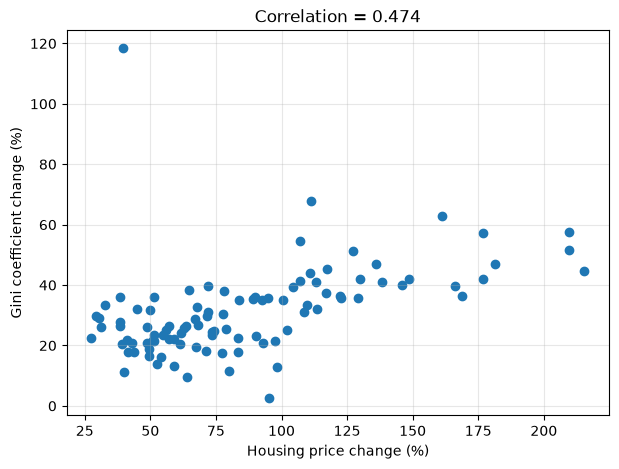

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(merged["change_pct"], merged["change"])

plt.xlabel("Housing price change (%)")
plt.ylabel("Gini coefficient change (%)")
plt.title(f"Correlation = {corr:.3f}")


plt.grid(alpha=0.3)
plt.show()

To conclude: The change in Gini is correlated with the change housing prices, given that the correlation value is if anything underestimated here, because of the outlier in the top-left. This indicates that the housing marked probably contributed to increasing inequality. But the results doesn't necessarily inply a causal connection. For example could it be possible that an omitted variable (e.g. income) is driving the results.

# Task 2 – Simulating the income distribution

The model itself is in `task2_model.py`. This notebook only runs the model, checks it and presents the results.

In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from task2_model import IncomeModel, gini

## 2.1 The model

The model follows 50,000 people from age 18 to 65. Each person draws an education, enters the labor market as unemployed after education, and then moves between employment and unemployment. Human capital changes over time and income depends on whether the person is studying, employed or unemployed.

The full model is coded in `task2_model.py`, as required in the assignment.

In [5]:
model = IncomeModel(seed=123)
model.simulate()

## 2.2 Simulate the income distribution

### 2.2.1 Check the simulation

First I check the education shares, the unemployment rate and the mean of the human-capital shock. These should be close to the values given in the assignment.

In [6]:
# a. education shares
education_shares = np.array([
    np.mean(model.education == e)
    for e in range(3)
])

print("Simulated education shares:", education_shares)
print("Expected education shares: ", model.p_e)

# b. unemployment
u_ss = model.sigma / (model.sigma + model.lambda_)

for age in [35, 45, 55, 65]:
    t = np.where(model.ages == age)[0][0]
    active = age >= model.age_min + model.education_years
    u_rate = np.mean(~model.employed[active, t])
    print(f"Unemployment age {age}: {u_rate:.4f}")

print(f"Steady-state unemployment: {u_ss:.4f}")

# c. check the hint about psi
rng = np.random.default_rng(123)
psi = rng.lognormal(
    -0.5 * model.sigma_psi**2,
    model.sigma_psi,
    size=model.N
)

print(f"Mean of psi: {psi.mean():.4f}")

Simulated education shares: [0.40006 0.35142 0.24852]
Expected education shares:  [0.4  0.35 0.25]
Unemployment age 35: 0.0787
Unemployment age 45: 0.0755
Unemployment age 55: 0.0758
Unemployment age 65: 0.0773
Steady-state unemployment: 0.0769
Mean of psi: 1.0003


The education shares are basically the 40%, 35% and 25% we put into the model. The unemployment rate is also very close to the steady-state value of about 7.7% at the later ages. The mean of `psi` is almost exactly 1. So the main checks look right.

### 2.2.2 Mean and selected percentiles

I use the 10th percentile, the median and the 90th percentile together with mean income.

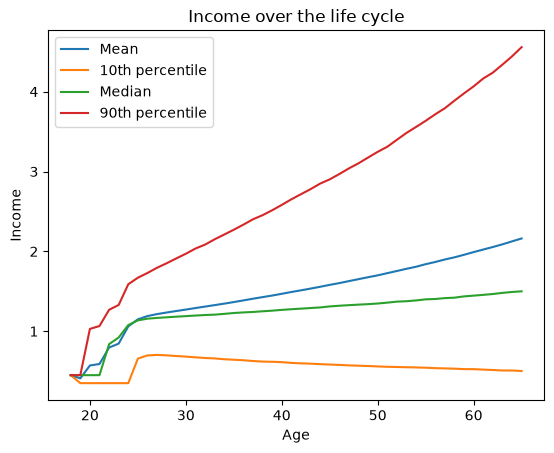

In [7]:
mean_income = np.mean(model.income, axis=0)
p10 = np.percentile(model.income, 10, axis=0)
p50 = np.percentile(model.income, 50, axis=0)
p90 = np.percentile(model.income, 90, axis=0)

plt.figure()

plt.plot(model.ages, mean_income, label="Mean")
plt.plot(model.ages, p10, label="10th percentile")
plt.plot(model.ages, p50, label="Median")
plt.plot(model.ages, p90, label="90th percentile")

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Income over the life cycle")
plt.legend()
plt.show()

Income increases over the life cycle, but the top of the distribution increases much faster. The gap between the 10th and 90th percentile therefore gets bigger with age.

### 2.2.3 Income distributions

The assignment asks for the income distribution at ages 25, 35, 45 and 60.

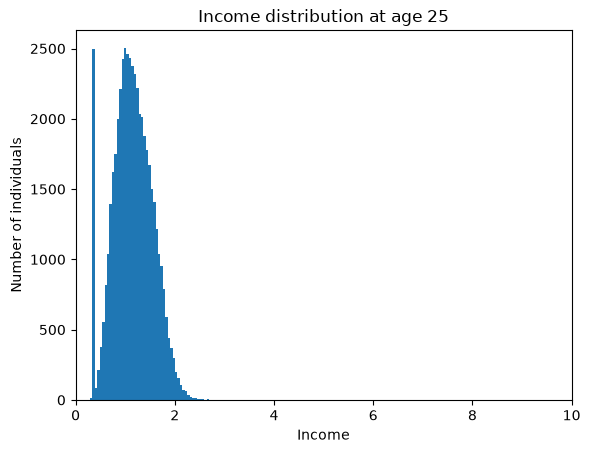

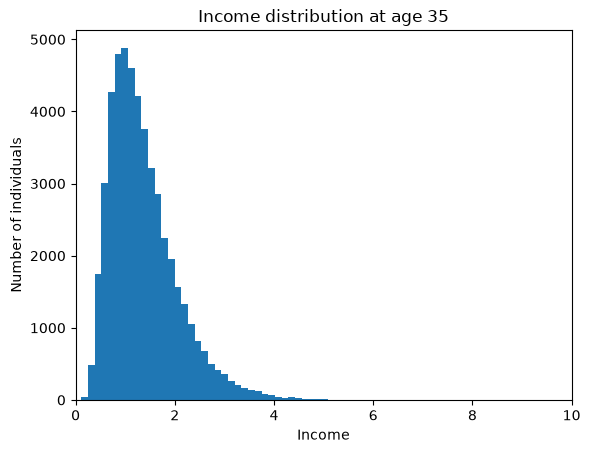

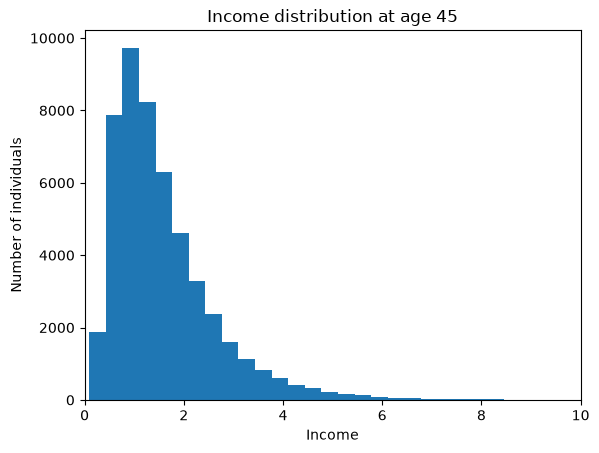

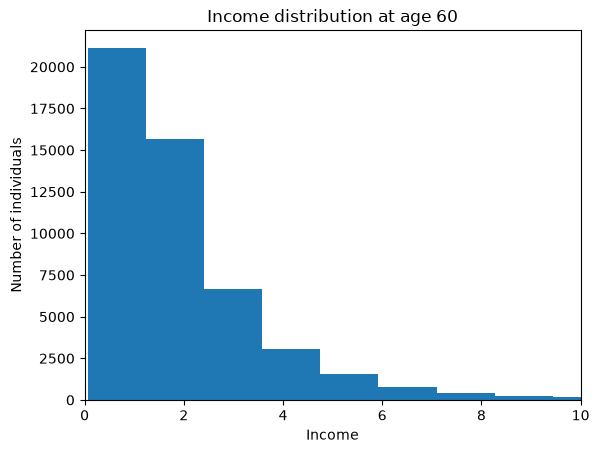

In [11]:
for age in [25, 35, 45, 60]:

    t = np.where(model.ages == age)[0][0]

    plt.figure()
    plt.hist(model.income[:, t], bins=50)

    plt.xlabel("Income")
    plt.ylabel("Number of individuals")
    plt.title(f"Income distribution at age {age}")

    plt.xlim(0, 10)

    plt.show()

The distribution gets more spread out as people get older. It also becomes more right-skewed, with a longer upper tail. This makes sense because differences in education, employment and human-capital shocks build up over time.

## 2.3 Compute the Gini coefficient

The Gini function is written in `task2_model.py`. I first test it on a uniform distribution on [0,1], where the answer should be 1/3.

In [44]:
rng = np.random.default_rng(123)
x_test = rng.uniform(0, 1, size=100_000)

print(f"Simulated Gini: {gini(x_test):.4f}")
print(f"Expected Gini:  {1 / 3:.4f}")

Simulated Gini: 0.3328
Expected Gini:  0.3333


The result is very close to 1/3, so the Gini function passes this simple check.

### 2.3.1 Full sample and Lorenz curve

I pool all people and all ages into one income vector and compute the Gini coefficient.

Gini, all ages pooled: 0.3758


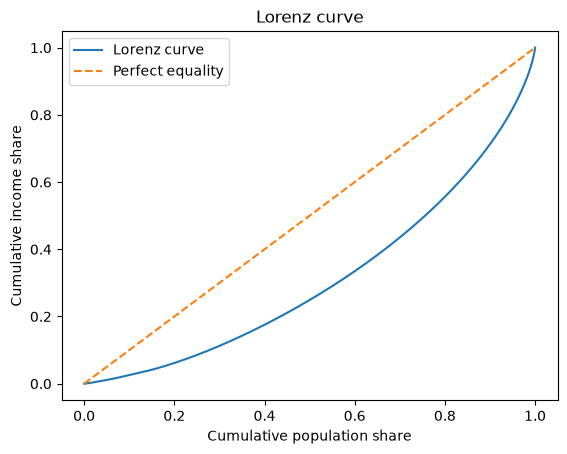

In [45]:
income_all = model.income.flatten()
gini_all = gini(income_all)

print(f"Gini, all ages pooled: {gini_all:.4f}")

income_sorted = np.sort(income_all)

income_share = (
    np.cumsum(income_sorted)
    / np.sum(income_sorted)
)

population_share = (
    np.arange(1, len(income_sorted) + 1)
    / len(income_sorted)
)

plt.figure()

plt.plot(
    population_share,
    income_share,
    label="Lorenz curve"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect equality"
)

plt.xlabel("Cumulative population share")
plt.ylabel("Cumulative income share")
plt.title("Lorenz curve")
plt.legend()
plt.show()

The pooled Gini is around 0.376. The Lorenz curve is clearly below the equality line, so there is a fair amount of income inequality in the simulated sample.

### 2.3.2 Gini by age

Now I compute the Gini separately at every age and compare it with the pooled Gini.

In [46]:
gini_age = np.array([
    gini(model.income[:, t])
    for t in range(len(model.ages))
])

for age in [18, 25, 35, 45, 60, 65]:
    t = np.where(model.ages == age)[0][0]
    print(f"Age {age}: {gini_age[t]:.4f}")

print(f"Average within-age Gini: {gini_age.mean():.4f}")
print(f"Pooled Gini:             {gini_all:.4f}")

Age 18: -0.0000
Age 25: 0.1944
Age 35: 0.2674
Age 45: 0.3374
Age 60: 0.4254
Age 65: 0.4521
Average within-age Gini: 0.3086
Pooled Gini:             0.3758


Inequality within an age group is lower than the pooled inequality on average. The pooled Gini also includes the difference between young and old people. Within-age inequality still rises a lot later in life because shocks and different employment histories have had more time to build up.

## 2.4 What drives inequality?

I switch off one part of the model at a time. I report the Gini for all ages pooled and for age 45, as suggested in the hint.

In [47]:
# a. baseline
baseline = IncomeModel(seed=123)
baseline.simulate()

# b. no educational differences
no_education = IncomeModel(
    seed=123,
    S_e=np.array([3, 3, 3]),
    h_e0=np.array([1.20, 1.20, 1.20]),
    delta_e=np.array([0.020, 0.020, 0.020])
)
no_education.simulate()

# c. no shocks to human capital
no_shocks = IncomeModel(seed=123, sigma_psi=0.0)
no_shocks.simulate()

# d. no depreciation while unemployed
no_depreciation = IncomeModel(seed=123, delta=0.0)
no_depreciation.simulate()

# e. no unemployment
no_unemployment = IncomeModel(seed=123)
no_unemployment.simulate(no_unemployment=True)

models = [
    baseline,
    no_education,
    no_shocks,
    no_depreciation,
    no_unemployment
]

names = [
    "Baseline",
    "No education differences",
    "No human-capital shocks",
    "No depreciation",
    "No unemployment"
]

t45 = np.where(baseline.ages == 45)[0][0]

for name, m in zip(names, models):

    G_all = gini(m.income)
    G_45 = gini(m.income[:, t45])

    print(
        f"{name:25s} "
        f"all ages = {G_all:.4f}, "
        f"age 45 = {G_45:.4f}"
    )

Baseline                  all ages = 0.3758, age 45 = 0.3374
No education differences  all ages = 0.3319, age 45 = 0.2896
No human-capital shocks   all ages = 0.2789, age 45 = 0.2144
No depreciation           all ages = 0.3812, age 45 = 0.3262
No unemployment           all ages = 0.3717, age 45 = 0.3251


The human-capital shocks matter the most in this simulation. When I remove them, the Gini falls the most, both for all ages and at age 45. Educational differences also matter quite a lot.

Removing depreciation or unemployment has a smaller effect. The pooled and age-45 Ginis do not always move exactly the same way. That is because the pooled Gini also includes differences between ages, while the age-45 Gini only compares people at the same age.

## 2.5 Extension: more risk

I add a permanent health shock. Each year there is a 2% risk of being hit. If it happens, human capital falls by 30%, and the job-separation probability increases from 5% to 15% from then on.

I chose this because it is a bigger change than just lowering income for one year. A bad health shock can affect both current and future income.

Baseline Gini, all ages:    0.3758
Health-risk Gini, all ages: 0.3814

Baseline Gini, age 45:      0.3374
Health-risk Gini, age 45:   0.3672

Share hit by health shock by age 65: 0.598


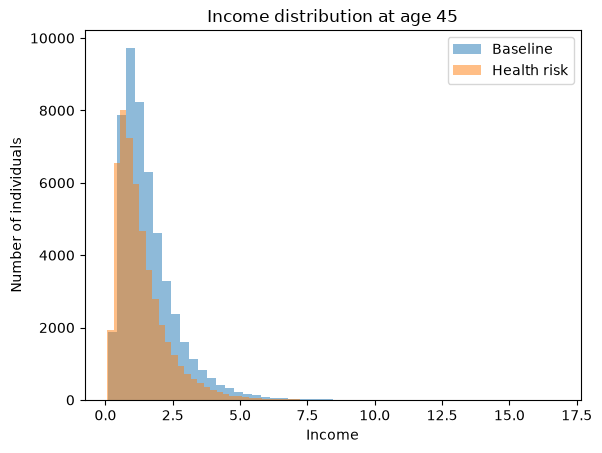

In [48]:
health_model = IncomeModel(seed=123)
health_model.simulate(health_risk=True)

G_base = gini(baseline.income)
G_health = gini(health_model.income)

G_base_45 = gini(baseline.income[:, t45])
G_health_45 = gini(health_model.income[:, t45])

print(f"Baseline Gini, all ages:    {G_base:.4f}")
print(f"Health-risk Gini, all ages: {G_health:.4f}")
print()
print(f"Baseline Gini, age 45:      {G_base_45:.4f}")
print(f"Health-risk Gini, age 45:   {G_health_45:.4f}")
print()
print(
    "Share hit by health shock by age 65: "
    f"{health_model.sick.mean():.3f}"
)

plt.figure()

plt.hist(
    baseline.income[:, t45],
    bins=50,
    alpha=0.5,
    label="Baseline"
)

plt.hist(
    health_model.income[:, t45],
    bins=50,
    alpha=0.5,
    label="Health risk"
)

plt.xlabel("Income")
plt.ylabel("Number of individuals")
plt.title("Income distribution at age 45")
plt.legend()
plt.show()

The health risk increases inequality. The pooled Gini rises from about 0.376 to 0.381, and at age 45 it rises from about 0.337 to 0.367. The histogram also gets more spread out towards lower incomes.

The reason is that some people are hit by a permanent loss of human capital and a higher risk of losing their job, while people who are not hit continue as before.